# ***ANALIZA ZBIORU DANYCH DANYCH ZAWIERAJĄCEGO INFORMACJE O POZIOMIE SZCZĘŚCIA MIESZKAŃCÓW PAŃSTWA I KONTYNENTÓW Z UWZGLĘDNIENIEM CZYNNIKÓW TAKICH JAK INFLACJA, PKB (World Happiness Index and Inflation Dataset)***

Źródłowy zbiór danych pobrany z Kaggle: https://www.kaggle.com/datasets/agrafintech/world-happiness-index-and-inflation-dataset/data



---


Wstępne importowanie bibliotek wykorzystywanych w analizie (pandas, numpy...)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



---


Wczytanie zawartości pliku .csv i utworzenie dataframe reprezentującego dane

In [2]:
dataframe = pd.read_csv('WHI_Inflation.csv', sep = '	')



---


Wstępny przegląd danych

In [3]:
dataframe.shape

(1203, 17)

In [4]:
dataframe.head()

,Country,Year,Rank,Score,GDP per Capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Energy Consumer Price Inflation,Food Consumer Price Inflation,GDP deflator Index growth rate,Headline Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation,Continent
0,Afghanistan,2015,153,3.575,0.319820,0.302850,0.303350,0.23414,0.365100,0.097190,-4.250000,-0.840000,2.665090,-0.660,0.219999,NaN,Asia
1,Afghanistan,2016,154,3.360,0.382270,0.110370,0.173440,0.16430,0.312680,0.071120,2.070000,5.670000,-2.409509,4.380,5.192760,NaN,Asia
2,Afghanistan,2017,141,3.794,0.401477,0.581543,0.180747,0.10618,0.311871,0.061158,4.440000,6.940000,2.404000,4.976,5.423228,NaN,Asia
3,Afghanistan,2018,145,3.632,0.332000,0.537000,0.255000,0.08500,0.191000,0.036000,1.474185,-1.045952,2.071208,0.630,-0.126033,NaN,Asia
4,Afghanistan,2019,154,3.203,0.350000,0.517000,0.361000,0.00000,0.158000,0.025000,-2.494359,3.794770,6.520928,2.302,NaN,NaN,Asia


In [5]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1203 entries, 0 to 1202
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 1203 non-null   object 
 1   Year                                    1203 non-null   int64  
 2   Rank                                    1203 non-null   int64  
 3   Score                                   1203 non-null   float64
 4   GDP per Capita                          1203 non-null   float64
 5   Social support                          1203 non-null   float64
 6   Healthy life expectancy at birth        1203 non-null   float64
 7   Freedom to make life choices            1203 non-null   float64
 8   Generosity                              1203 non-null   float64
 9   Perceptions of corruption               1202 non-null   float64
 10  Energy Consumer Price Inflation         1074 non-null   floa

In [6]:
dataframe.describe()

,Year,Rank,Score,GDP per Capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Energy Consumer Price Inflation,Food Consumer Price Inflation,GDP deflator Index growth rate,Headline Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation
count,1203.000000,1203.000000,1203.000000,1203.000000,1203.000000,1203.000000,1203.000000,1203.000000,1202.000000,1074.000000,1114.000000,1187.000000,1180.000000,720.000000,757.000000
mean,2018.868662,73.975062,5.503177,2.797294,0.983193,21.676503,0.553649,0.139070,0.326027,6.406440,8.036627,6.942309,7.392601,3.517293,5.691213
std,2.551181,44.776420,1.138402,3.547966,0.302705,30.421780,0.221108,0.164132,0.312013,16.686408,26.342455,31.771016,25.370648,5.535930,13.384842
min,2015.000000,1.000000,1.859000,0.000000,0.000000,0.000000,0.000000,-0.300907,0.000000,-23.879999,-22.030001,-26.100000,-3.752996,-28.619415,-83.339781
25%,2017.000000,35.000000,4.624300,0.800500,0.799505,0.582975,0.405480,0.045635,0.074265,0.596688,1.276331,1.353737,1.392791,1.055030,-0.296023
50%,2019.000000,72.000000,5.546000,1.164920,0.934000,0.792566,0.546040,0.145785,0.160825,2.736892,3.714004,3.176209,3.445729,2.246837,2.729256
75%,2021.000000,113.000000,6.346150,1.704000,1.214504,59.512076,0.729000,0.235854,0.660000,7.067111,9.269121,6.996021,6.751251,4.672530,8.053405
max,2023.000000,158.000000,7.842000,11.660000,1.644000,76.953000,0.974998,0.838075,0.939000,306.431673,601.020236,812.247463,557.210000,58.851863,128.476638




---

Przygotowanie kolorów do wykorzystania na wykresach - żeby uniknąć definiowania ich ręcznie pod każdym wykresem

In [7]:
# Valid or invalid values
valid_invalid_colors = ['#3BBE58', '#CE574C']
valid = '#3BBE58'
invalid = '#CE574C'

# Continents
continent_colors = ['#ff8c1a', '#008040', '#3399ff', '#9933ff', '#86b300', '#006699']
africa_color = '#ff8c1a'
asia_color = '#008040'
europe_color = '#3399ff'
north_america_color = '#9933ff'
south_america_color = '#86b300'
oceania_color = '#006699'

# Inflation
inflation_colors = ['#6600FF', '#FFDB4D', '#505050', '#CC6600']
ppi_color = '#6600FF'
ecpi_color = '#FFDB4D'
occpi_color = '#505050'
fcpi_color = '#CC6600'



---


Wynajdywanie kolumn z pustymi wartościami i ilustrowanie udziału pustych wartości

In [8]:
dataframe.isnull().sum()

,0
Country,0
Year,0
Rank,0
Score,0
GDP per Capita,0
Social support,0
Healthy life expectancy at birth,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,1


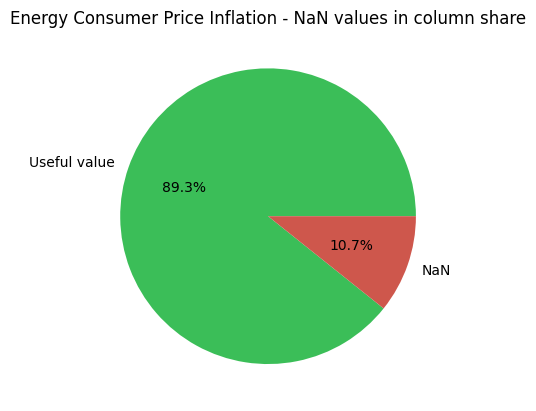

In [9]:
ecpi = dataframe['Energy Consumer Price Inflation']
labels = ['Useful value', 'NaN']
values = ecpi.count(), ecpi.isnull().sum()
fig, ax = plt.subplots()
ax.pie(values, labels = labels, colors = valid_invalid_colors, autopct = '%1.1f%%')
plt.title('Energy Consumer Price Inflation - NaN values in column share')
plt.show()

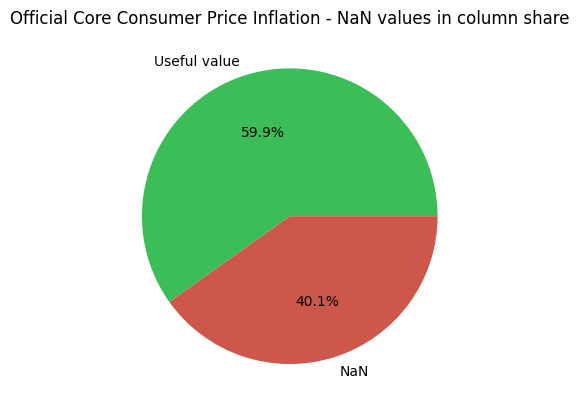

In [10]:
occpi = dataframe['Official Core Consumer Price Inflation']
values = occpi.count(), occpi.isnull().sum()
fig, ax = plt.subplots()
ax.pie(values, labels = labels, colors = valid_invalid_colors, autopct = '%1.1f%%')
plt.title('Official Core Consumer Price Inflation - NaN values in column share')
plt.show()

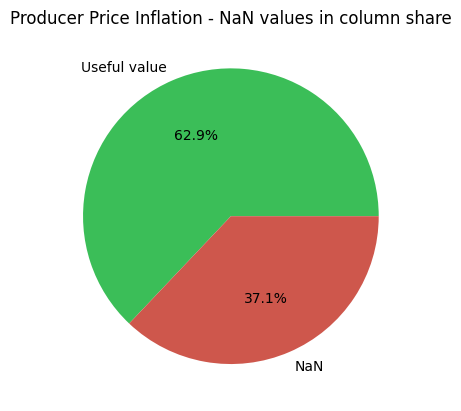

In [11]:
ppi = dataframe['Producer Price Inflation']
values = ppi.count(), ppi.isnull().sum()
fig, ax = plt.subplots()
ax.pie(values, labels = labels, colors = valid_invalid_colors, autopct = '%1.1f%%')
plt.title('Producer Price Inflation - NaN values in column share')
plt.show()



---


Uzupełnienie pustych wartości średnimi wartościami w danej kolumnie

In [12]:
mean = dataframe['Energy Consumer Price Inflation'].mean()
dataframe['Energy Consumer Price Inflation'].fillna(mean, inplace = True)

In [13]:
mean = dataframe['Official Core Consumer Price Inflation'].mean()
dataframe['Official Core Consumer Price Inflation'].fillna(mean, inplace = True)

In [14]:
mean = dataframe['Producer Price Inflation'].mean()
dataframe['Producer Price Inflation'].fillna(mean, inplace = True)

In [15]:
dataframe.isnull().sum()

,0
Country,0
Year,0
Rank,0
Score,0
GDP per Capita,0
Social support,0
Healthy life expectancy at birth,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,1




---

Przegląd państw i kontynentów

In [16]:
africa_countries = dataframe[dataframe['Continent'] == 'Africa'].count()['Continent']
asia_countries = dataframe[dataframe['Continent'] == 'Asia'].count()['Continent']
europe_countries = dataframe[dataframe['Continent'] == 'Europe'].count()['Continent']
north_america_countries = dataframe[dataframe['Continent'] == 'North America'].count()['Continent']
south_america_countries = dataframe[dataframe['Continent'] == 'South America'].count()['Continent']
oceania_countries = dataframe[dataframe['Continent'] == 'Oceania'].count()['Continent']

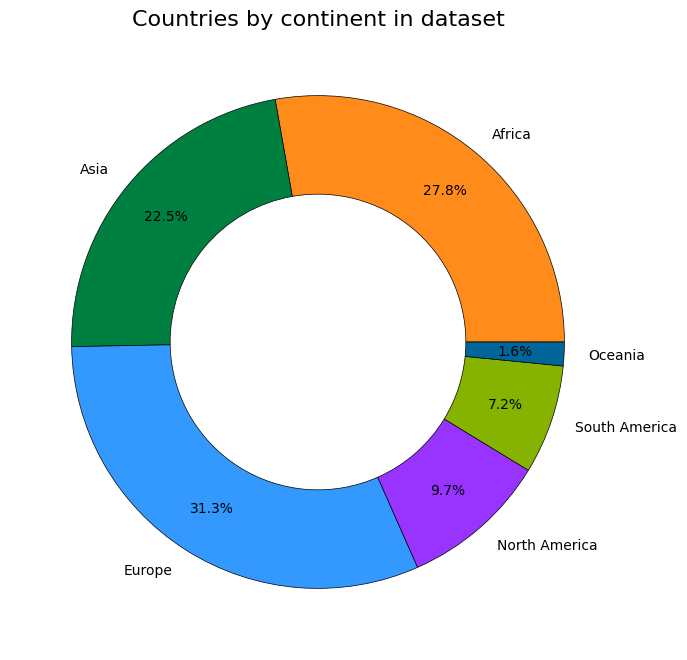

In [17]:
def format_autopct(pct):
    return f'{pct:.1f}%'

colors = continent_colors
values = africa_countries, asia_countries, europe_countries, north_america_countries, south_america_countries, oceania_countries
labels = ['Africa', 'Asia', 'Europe', 'North America', 'South America', 'Oceania']
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(values, labels=labels, wedgeprops=dict(width=0.4, edgecolor='black', linewidth=0.5), autopct=lambda pct: format_autopct(pct), pctdistance=0.8, colors=colors, textprops={'fontsize':10})
plt.title('Countries by continent in dataset', fontsize=16)
plt.show()



---


Zależność indeksu szczęścia obywateli państw i kontynentów


In [18]:
import matplotlib.colors as mcolors

In [19]:
# maximum and minimum happiness index values for color normalization
minimum_happiness = dataframe['Score'].min()
maximum_happiness = dataframe['Score'].max()

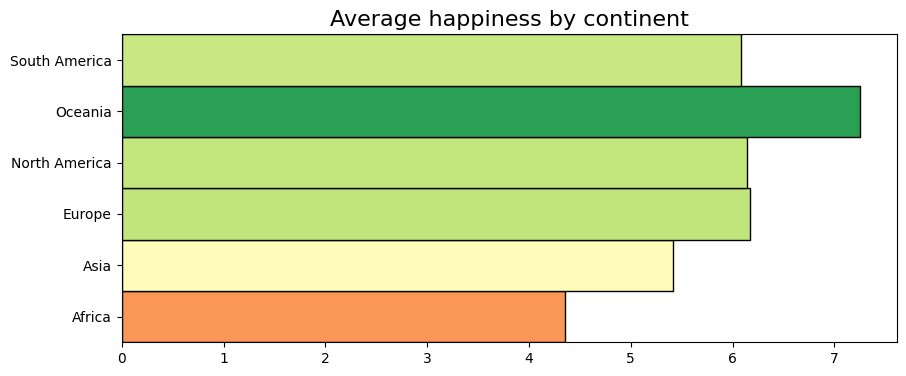

In [20]:
# ALL CONTINENTS SUMMARY
avg_index_by_continent = dataframe.groupby('Continent')['Score'].mean()
categories = avg_index_by_continent.index
values = avg_index_by_continent.values

# plot customization - colors
norm = mcolors.Normalize(vmin=minimum_happiness + 1.25, vmax=maximum_happiness) # small adjustment for better contrast between continents
cmap = plt.cm.RdYlGn
colors = cmap(norm(values))

# plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.grid(False)
ax.set_ylim(-0.5, len(categories) - 0.5)
ax.barh(categories, values, edgecolor="black", linewidth=1, color=colors, height=1)
plt.title('Average happiness by continent', fontsize=16)
plt.show()

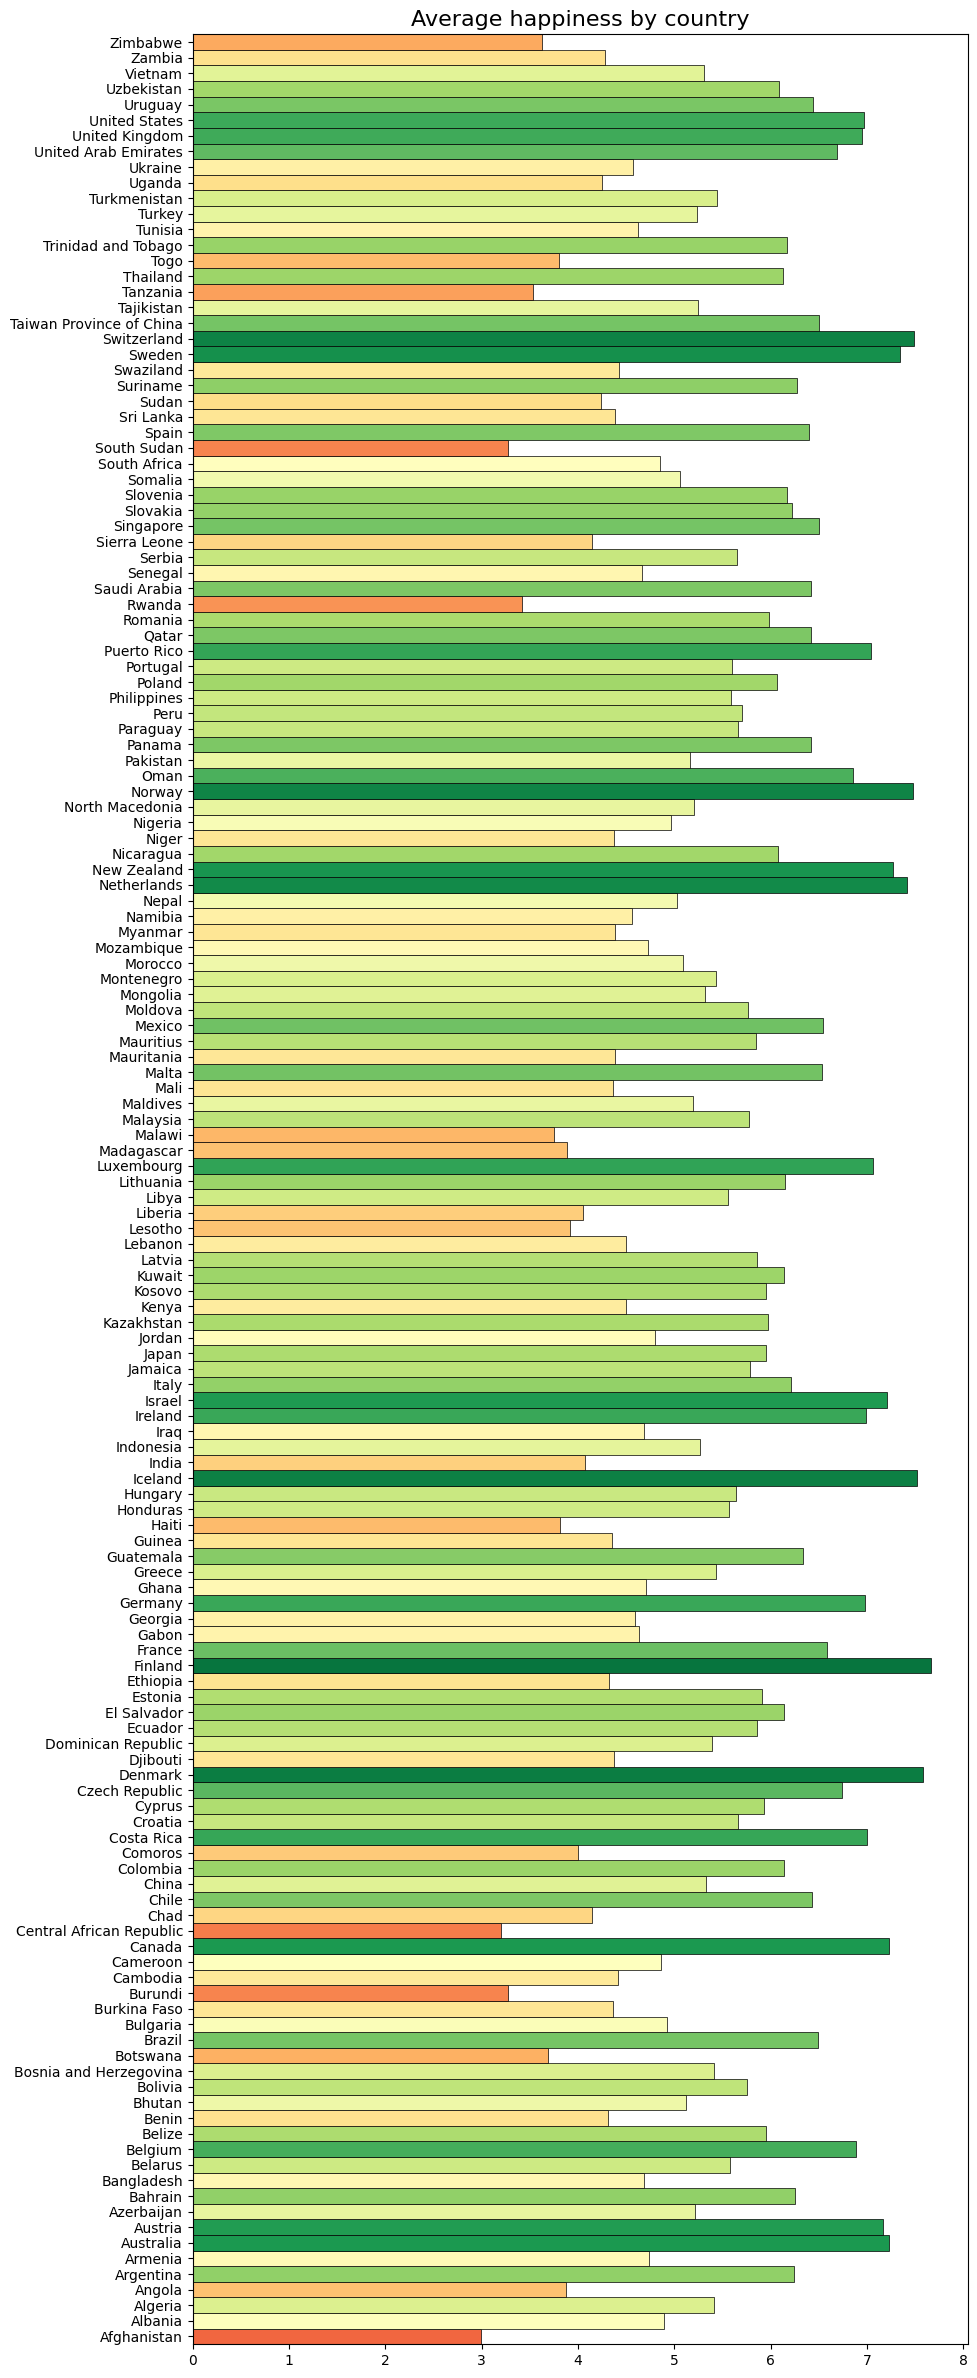

In [21]:
# ALL COUNTRIES SUMMARY
avg_index_by_country = dataframe.groupby('Country')['Score'].mean()
categories = avg_index_by_country.index
values = avg_index_by_country.values

# plot customization - colors
norm = mcolors.Normalize(vmin=minimum_happiness, vmax=maximum_happiness)
cmap = plt.cm.RdYlGn
colors = cmap(norm(values))

# plot
fig, ax = plt.subplots(figsize=(10, 30))
ax.grid(False)
ax.set_ylim(-0.5, len(categories) - 0.5)
ax.barh(categories, values, edgecolor="black", linewidth=0.5, color=colors, height=1)
plt.title('Average happiness by country', fontsize=16)
plt.show()

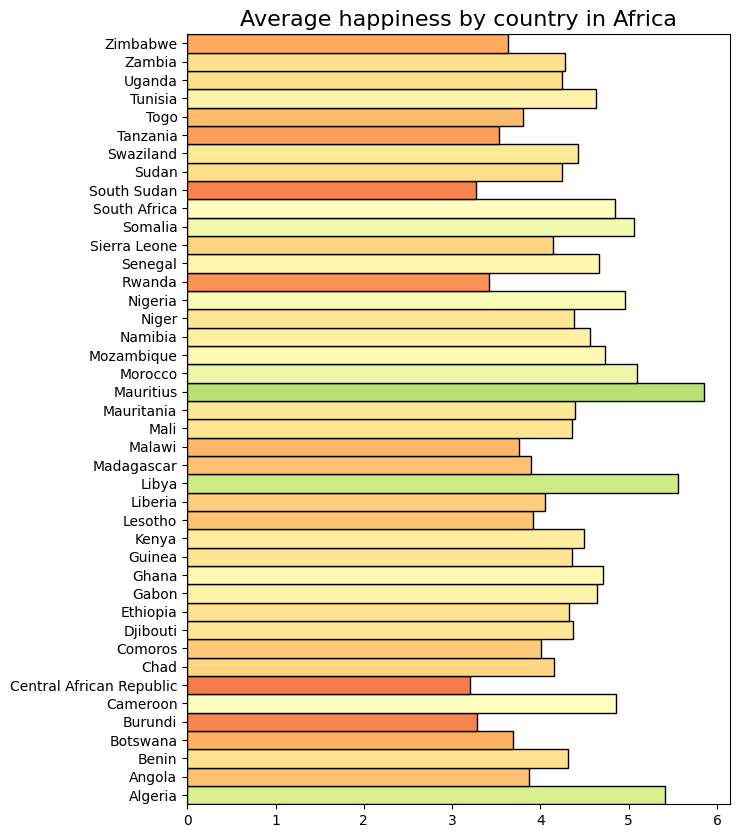

In [22]:
# AFRICAN COUNTRIES
avg_africa_countries_happiness = dataframe[dataframe['Continent'] == 'Africa'].groupby('Country')['Score'].mean()
categories = avg_africa_countries_happiness.index
values = avg_africa_countries_happiness.values

# plot customization - colors
norm = mcolors.Normalize(vmin=minimum_happiness, vmax=maximum_happiness)
cmap = plt.cm.RdYlGn
colors = cmap(norm(values))

# plot
fig, ax = plt.subplots(figsize=(7, 10))
ax.grid(False)
ax.set_ylim(-0.5, len(categories) - 0.5)
ax.barh(categories, values, height=1, edgecolor="black", linewidth=1, color=colors)
plt.title('Average happiness by country in Africa', fontsize=16)
plt.yticks(ticks=categories, rotation=0)
plt.show()

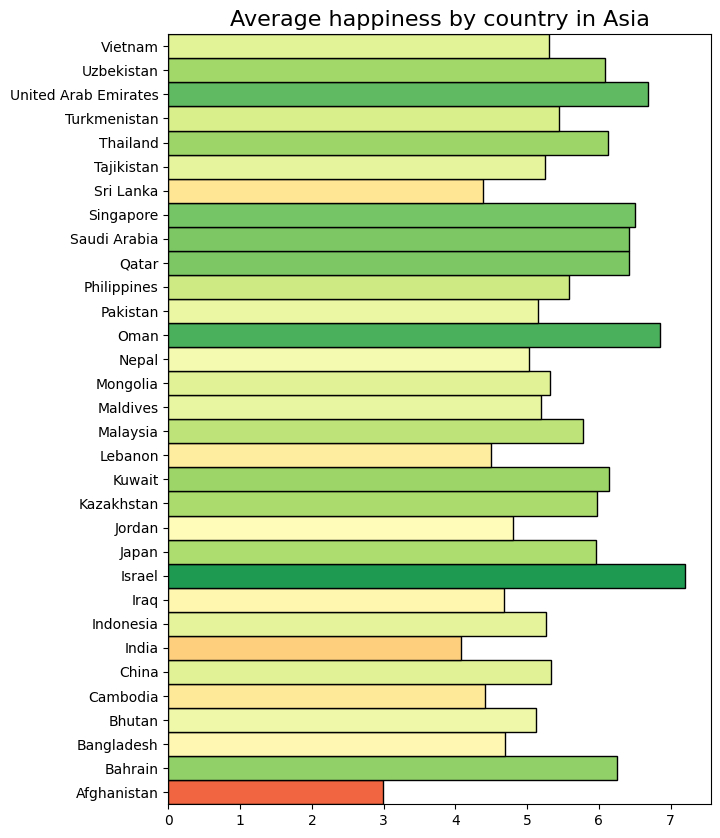

In [23]:
# ASIAN COUNTRIES
avg_asia_countries_happiness = dataframe[dataframe['Continent'] == 'Asia'].groupby('Country')['Score'].mean()
categories = avg_asia_countries_happiness.index
values = avg_asia_countries_happiness.values

# plot customization - colors
norm = mcolors.Normalize(vmin=minimum_happiness, vmax=maximum_happiness)
cmap = plt.cm.RdYlGn
colors = cmap(norm(values))

# plot
fig, ax = plt.subplots(figsize=(7, 10))
ax.grid(False)
ax.set_ylim(-0.5, len(categories) - 0.5)
ax.barh(categories, values, height=1, edgecolor="black", linewidth=1, color=colors)
plt.title('Average happiness by country in Asia', fontsize=16)
plt.yticks(ticks=categories, rotation=0)
plt.show()

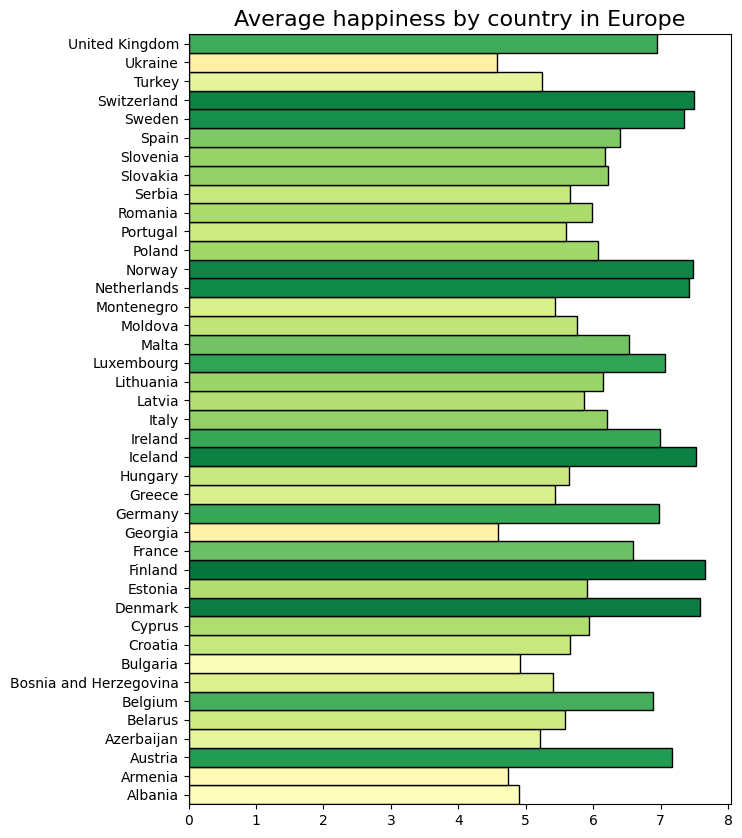

In [24]:
# EUROPEAN COUNTRIES
avg_europe_countries_happiness = dataframe[dataframe['Continent'] == 'Europe'].groupby('Country')['Score'].mean()
categories = avg_europe_countries_happiness.index
values = avg_europe_countries_happiness.values

# plot customization - colors
norm = mcolors.Normalize(vmin=minimum_happiness, vmax=maximum_happiness)
cmap = plt.cm.RdYlGn
colors = cmap(norm(values))

# plot
fig, ax = plt.subplots(figsize=(7, 10))
ax.grid(False)
ax.set_ylim(-0.5, len(categories) - 0.5)
ax.barh(categories, values, height=1, edgecolor="black", linewidth=1, color=colors)
plt.title('Average happiness by country in Europe', fontsize=16)
plt.yticks(ticks=categories, rotation=0)
plt.show()

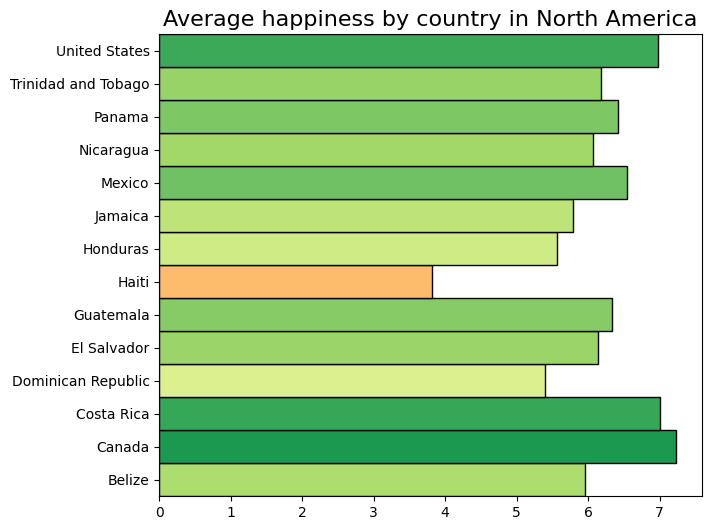

In [25]:
# NORTH AMERICAN COUNTRIES
avg_north_america_countries_happiness = dataframe[dataframe['Continent'] == 'North America'].groupby('Country')['Score'].mean()
categories = avg_north_america_countries_happiness.index
values = avg_north_america_countries_happiness.values

# plot customization - colors
norm = mcolors.Normalize(vmin=minimum_happiness, vmax=maximum_happiness)
cmap = plt.cm.RdYlGn
colors = cmap(norm(values))

# plot
fig, ax = plt.subplots(figsize=(7, 6))
ax.grid(False)
ax.set_ylim(-0.5, len(categories) - 0.5)
ax.barh(categories, values, height=1, edgecolor="black", linewidth=1, color=colors)
plt.title('Average happiness by country in North America', fontsize=16)
plt.yticks(ticks=categories, rotation=0)
plt.show()

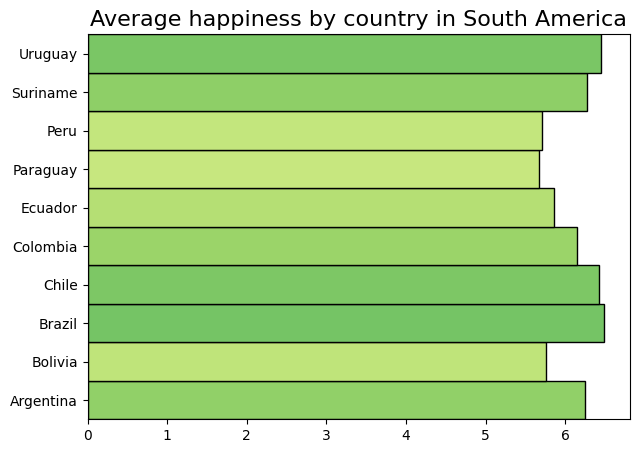

In [26]:
# SOUTH AMERICAN COUNTRIES
avg_south_america_countries_happiness = dataframe[dataframe['Continent'] == 'South America'].groupby('Country')['Score'].mean()
categories = avg_south_america_countries_happiness.index
values = avg_south_america_countries_happiness.values

# plot customization - colors
norm = mcolors.Normalize(vmin=minimum_happiness, vmax=maximum_happiness)
cmap = plt.cm.RdYlGn
colors = cmap(norm(values))

# plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.grid(False)
ax.set_ylim(-0.5, len(categories) - 0.5)
ax.barh(categories, values, height=1, edgecolor="black", linewidth=1, color=colors)
plt.title('Average happiness by country in South America', fontsize=16)
plt.yticks(ticks=categories, rotation=0)
plt.show()

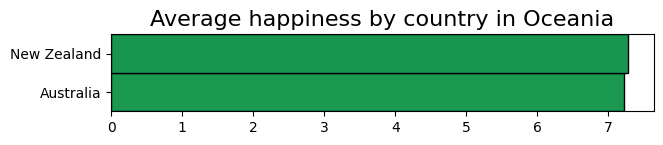

In [27]:
# OCEANIAN COUNTRIES
avg_oceania_countries_happiness = dataframe[dataframe['Continent'] == 'Oceania'].groupby('Country')['Score'].mean()
categories = avg_oceania_countries_happiness.index
values = avg_oceania_countries_happiness.values

# plot customization - colors
norm = mcolors.Normalize(vmin=minimum_happiness, vmax=maximum_happiness)
cmap = plt.cm.RdYlGn
colors = cmap(norm(values))

# plot
fig, ax = plt.subplots(figsize=(7, 1))
ax.grid(False)
ax.set_ylim(-0.5, len(categories) - 0.5)
ax.barh(categories, values, height=1, edgecolor="black", linewidth=1, color=colors)
plt.title('Average happiness by country in Oceania', fontsize=16)
plt.yticks(ticks=categories, rotation=0)
plt.show()



---

Zmiana indeksu szczęśliwości społeczeństw na przestrzeni lat

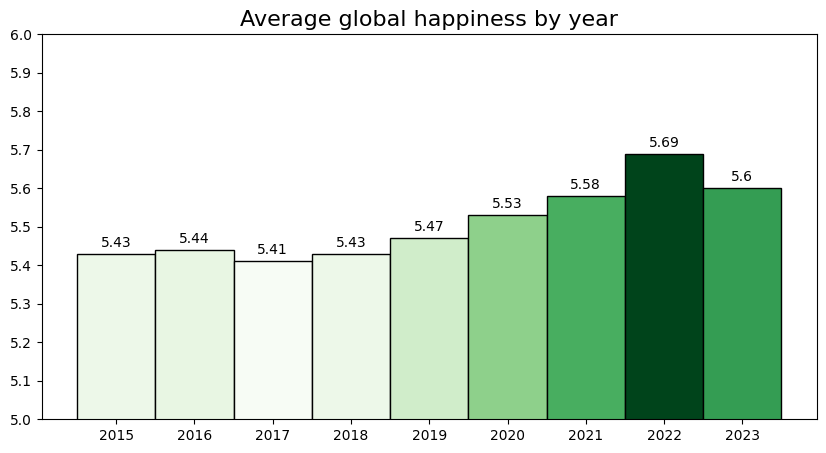

In [28]:
# GLOBAL HAPPINESS SUMMARY
avg_index_by_year = dataframe.groupby('Year')['Score'].mean()
categories = avg_index_by_year.index.tolist()
values = np.array(avg_index_by_year.values).round(2)

# plot customization - colors
norm = mcolors.Normalize(vmin=min(values), vmax=max(values))
cmap = plt.cm.Greens
colors = cmap(norm(values))

# plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.grid(False)
bars = ax.bar(categories, values, edgecolor="black", linewidth=1, color=colors, width=1)
ax.bar_label(bars, padding=3, label_type="edge", fontsize=10)
ax.set_ylim(min(values) - 0.5, max(values) + 0.5)

plt.title('Average global happiness by year', fontsize=16)
plt.xticks(ticks=categories, rotation=0)
plt.yticks(ticks=np.arange(5, 6.1, 0.1))
ax.set_ylim(5, 6)
plt.show()

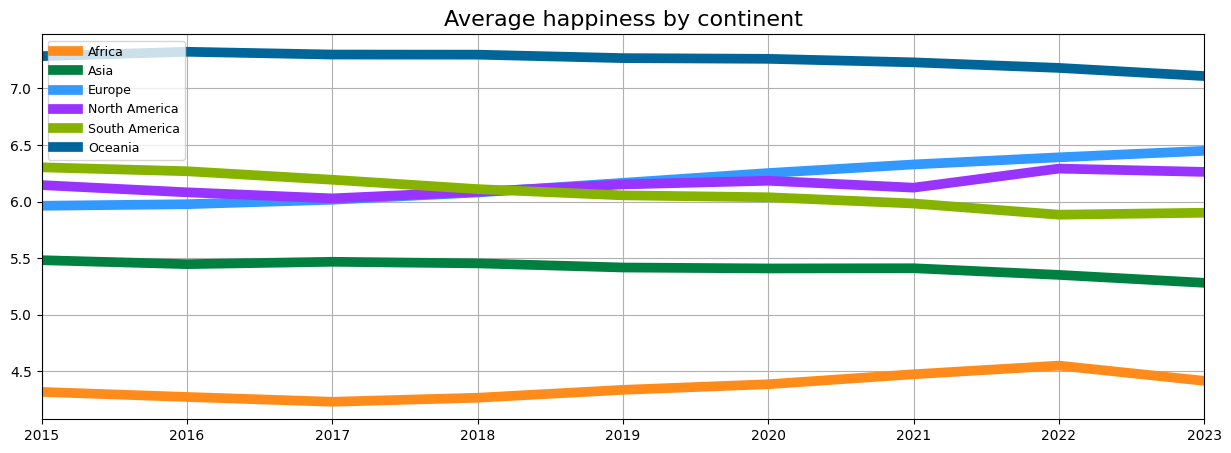

In [29]:
# CONTINENT HAPPINESS OVER YEARS
avg_africa_happiness_by_year = dataframe[dataframe['Continent'] == 'Africa'].groupby('Year')['Score'].mean()
avg_asia_happiness_by_year = dataframe[dataframe['Continent'] == 'Asia'].groupby('Year')['Score'].mean()
avg_europe_happiness_by_year = dataframe[dataframe['Continent'] == 'Europe'].groupby('Year')['Score'].mean()
avg_north_america_happiness_by_year = dataframe[dataframe['Continent'] == 'North America'].groupby('Year')['Score'].mean()
avg_south_america_happiness_by_year = dataframe[dataframe['Continent'] == 'South America'].groupby('Year')['Score'].mean()
avg_oceania_happiness_by_year = dataframe[dataframe['Continent'] == 'Oceania'].groupby('Year')['Score'].mean()

fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlim(2015, 2023)

plt.plot(avg_africa_happiness_by_year.index, avg_africa_happiness_by_year.values, color=africa_color, linewidth=7, linestyle='solid', label='Africa')
plt.plot(avg_asia_happiness_by_year.index, avg_asia_happiness_by_year.values, color=asia_color, linewidth=7, linestyle='solid', label='Asia')
plt.plot(avg_europe_happiness_by_year.index, avg_europe_happiness_by_year.values, color=europe_color, linewidth=7, linestyle='solid', label='Europe')
plt.plot(avg_north_america_happiness_by_year.index, avg_north_america_happiness_by_year.values, color=north_america_color, linewidth=7, linestyle='solid', label='North America')
plt.plot(avg_south_america_happiness_by_year.index, avg_south_america_happiness_by_year.values, color=south_america_color, linewidth=7, linestyle='solid', label='South America')
plt.plot(avg_oceania_happiness_by_year.index, avg_oceania_happiness_by_year.values, color=oceania_color, linewidth=7, linestyle='solid', label='Oceania')

ax.legend(loc="upper left", fontsize=9)
plt.title('Average happiness by continent', fontsize=16)
plt.xticks(ticks=np.arange(2015, 2024, 1))
ax.grid(True)
plt.show()



---


PKB per capita

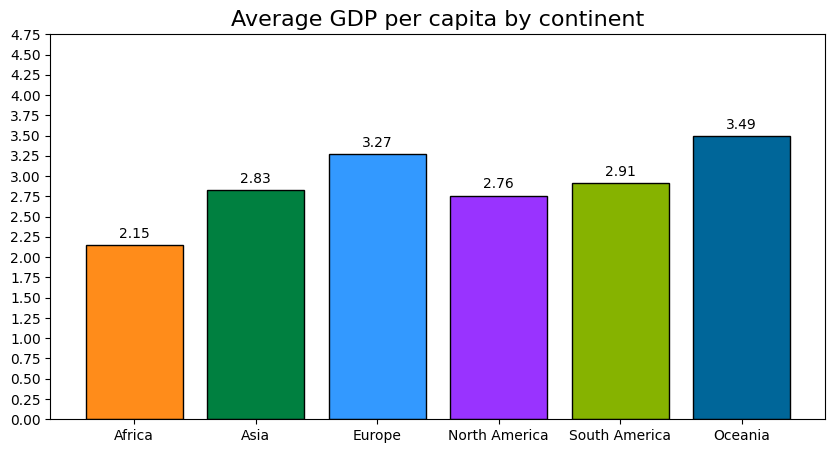

In [30]:
# GPD PER CAPITA BY CONTINENT
gdp_pc_africa = dataframe['GDP per Capita'].where(dataframe['Continent'] == 'Africa').mean().round(2)
gdp_pc_asia = dataframe['GDP per Capita'].where(dataframe['Continent'] == 'Asia').mean().round(2)
gdp_pc_europe = dataframe['GDP per Capita'].where(dataframe['Continent'] == 'Europe').mean().round(2)
gdp_pc_north_america = dataframe['GDP per Capita'].where(dataframe['Continent'] == 'North America').mean().round(2)
gdp_pc_south_america = dataframe['GDP per Capita'].where(dataframe['Continent'] == 'South America').mean().round(2)
gdp_pc_oceania = dataframe['GDP per Capita'].where(dataframe['Continent'] == 'Oceania').mean().round(2)

arguments = ('Africa', 'Asia', 'Europe', 'North America', 'South America', 'Oceania')
values = (gdp_pc_africa, gdp_pc_asia, gdp_pc_europe, gdp_pc_north_america, gdp_pc_south_america, gdp_pc_oceania)
colors = ['#ff8c1a', '#008040', '#3399ff', '#9933ff', '#86b300', '#006699']
fig, ax = plt.subplots(figsize=(10, 5))
rects = ax.bar(arguments, values, edgecolor='black', linewidth=1.0, color=colors)
ax.bar_label(rects, padding=3, label_type="edge", fontsize=10)
ax.set_yticks(np.arange(0, 5, 0.25))
plt.title('Average GDP per capita by continent', fontsize=16)
plt.show()



---

Kraje z najwyższym i najniższym indeksem szczęśliwości

In [31]:
happiest_countries = dataframe.groupby('Country')['Score'].mean().nlargest(10).reset_index()
happiest_countries

,Country,Score
0,Finland,7.662744
1,Denmark,7.579733
2,Iceland,7.522278
3,Switzerland,7.493322
4,Norway,7.473889
5,Netherlands,7.417100
6,Sweden,7.343500
7,New Zealand,7.273844
8,Canada,7.230456
9,Australia,7.227089


In [32]:
finland = dataframe[dataframe['Country'] == 'Finland'].groupby('Year')['Score'].mean().reset_index()
denmark = dataframe[dataframe['Country'] == 'Denmark'].groupby('Year')['Score'].mean().reset_index()
iceland = dataframe[dataframe['Country'] == 'Iceland'].groupby('Year')['Score'].mean().reset_index()
switzerland = dataframe[dataframe['Country'] == 'Switzerland'].groupby('Year')['Score'].mean().reset_index()
norway = dataframe[dataframe['Country'] == 'Norway'].groupby('Year')['Score'].mean().reset_index()

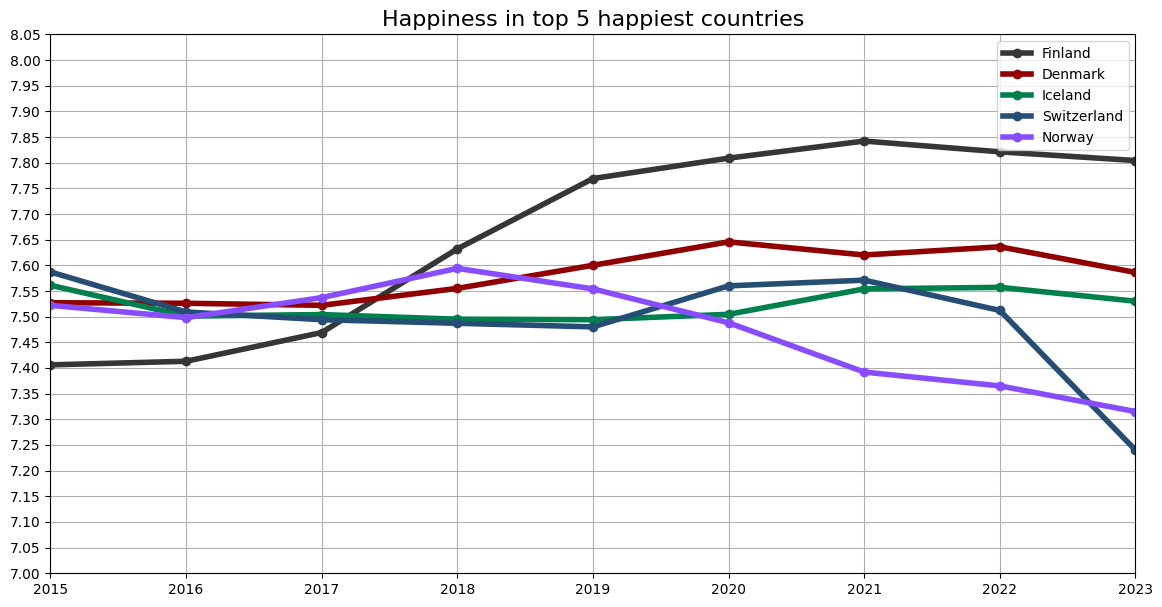

In [33]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(2015, 2023)
plt.plot(finland['Year'], finland['Score'], 'o-', label='Finland', linewidth=4, color='#363636')
plt.plot(denmark['Year'], denmark['Score'], 'o-', label='Denmark', linewidth=4, color='#900000')
plt.plot(iceland['Year'], iceland['Score'], 'o-', label='Iceland', linewidth=4, color='#00804d')
plt.plot(switzerland['Year'], switzerland['Score'], 'o-', label='Switzerland', linewidth=4, color='#264d73')
plt.plot(norway['Year'], norway['Score'], 'o-', label='Norway', linewidth=4, color='#884dff')
ax.grid(True)
plt.yticks(ticks=np.arange(7, 8.1, 0.05))
plt.legend()
plt.title('Happiness in top 5 happiest countries', fontsize=16)
plt.show()

In [34]:
unhappiest_countries = dataframe.groupby('Country')['Score'].mean().nsmallest(10)
unhappiest_countries

,Score
Country,
Afghanistan,2.990767
Central African Republic,3.202580
South Sudan,3.269320
Burundi,3.277900
Rwanda,3.417186
Tanzania,3.536133
Zimbabwe,3.630689
Botswana,3.691362
Malawi,3.755333


In [35]:
afghanistan = dataframe[dataframe['Country'] == 'Afghanistan'].groupby('Year')['Score'].mean()
central_african_republic = dataframe[dataframe['Country'] == 'Central African Republic'].groupby('Year')['Score'].mean()
south_sudan = dataframe[dataframe['Country'] == 'South Sudan'].groupby('Year')['Score'].mean()
burundi = dataframe[dataframe['Country'] == 'Burundi'].groupby('Year')['Score'].mean()
rwanda = dataframe[dataframe['Country'] == 'Rwanda'].groupby('Year')['Score'].mean()

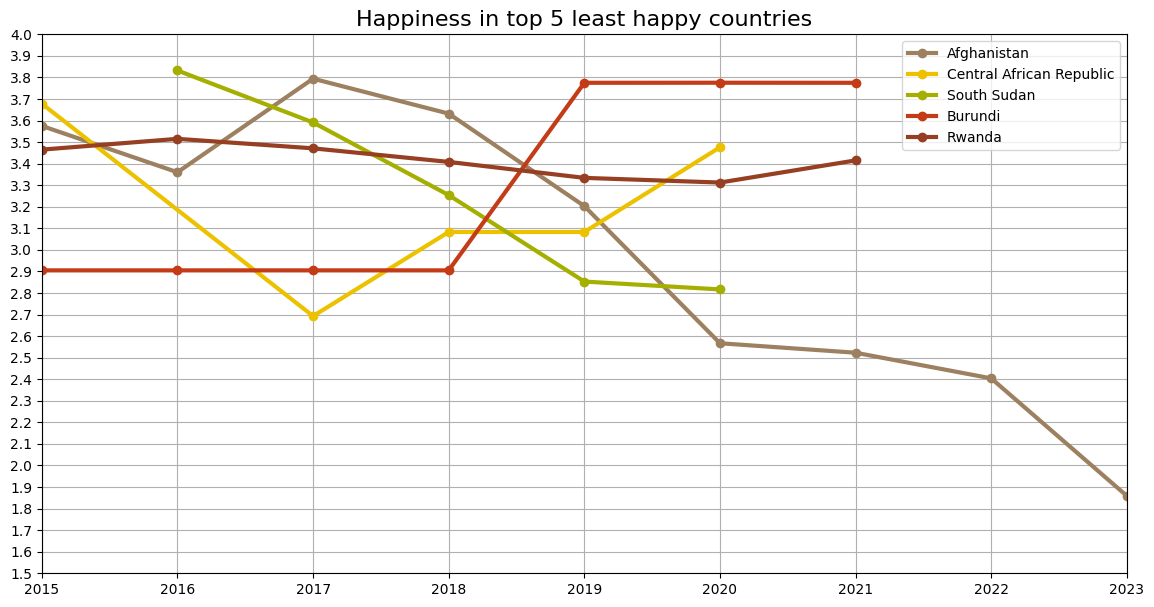

In [36]:
fig, ax = plt.subplots(figsize=(14, 7))
plt.xlim(2015, 2023)
plt.plot(afghanistan.index, afghanistan.values, 'o-', label='Afghanistan', linewidth=3, color='#9c8060')
plt.plot(central_african_republic.index, central_african_republic.values, 'o-', label='Central African Republic', linewidth=3, color='#ecc200')
plt.plot(south_sudan.index, south_sudan.values, 'o-', label='South Sudan', linewidth=3, color='#a5af00')
plt.plot(burundi.index, burundi.values, 'o-', label='Burundi', linewidth=3, color='#c43b17')
plt.plot(rwanda.index, rwanda.values, 'o-', label='Rwanda', linewidth=3, color='#963f22')
ax.grid(True)
plt.yticks(ticks=np.arange(1.5, 4.1, 0.1))
plt.legend()
plt.title('Happiness in top 5 least happy countries', fontsize=16)
plt.show()

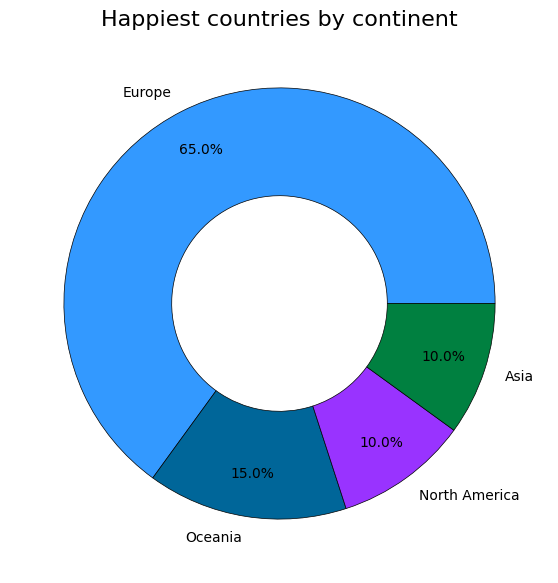

In [37]:
top_20_coutriest_happiness = dataframe.groupby(['Country', 'Continent'])['Score'].mean().nlargest(20).reset_index()

labels = top_20_coutriest_happiness['Continent'].unique()
values = top_20_coutriest_happiness['Continent'].value_counts()
colors = [europe_color, oceania_color, north_america_color, asia_color]

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(values, labels=labels, wedgeprops=dict(width=0.5, edgecolor='black', linewidth=0.5), autopct='%1.1f%%', pctdistance=0.8, colors=colors, textprops={'fontsize':10})
plt.title('Happiest countries by continent', fontsize=16)
plt.show()

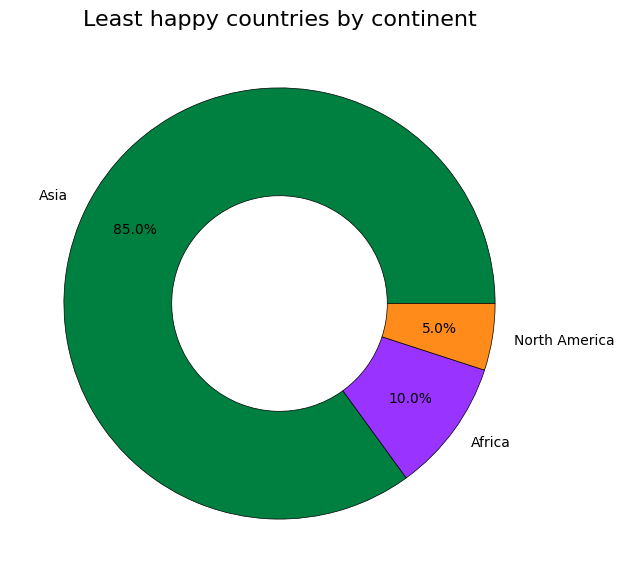

In [38]:
least_20_countries_happiness = dataframe.groupby(['Country', 'Continent'])['Score'].mean().nsmallest(20).reset_index()

labels = least_20_countries_happiness['Continent'].unique()
values = least_20_countries_happiness['Continent'].value_counts()
colors = [asia_color, north_america_color, africa_color]

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(values, labels=labels, wedgeprops=dict(width=0.5, edgecolor='black', linewidth=0.5), autopct='%1.1f%%', pctdistance=0.75, colors=colors, textprops={'fontsize':10})
plt.title('Least happy countries by continent', fontsize=16)
plt.show()



---

Inflacja w kontekście państw i kontynentów

In [39]:
ppi_by_continent = dataframe.groupby('Continent')['Producer Price Inflation'].mean().round(2)
ecpi_by_continent = dataframe.groupby('Continent')['Energy Consumer Price Inflation'].mean().round(2)
occpi_by_continent = dataframe.groupby('Continent')['Official Core Consumer Price Inflation'].mean().round(2)
fcpi_by_continent = dataframe.groupby('Continent')['Food Consumer Price Inflation'].mean().round(2)

In [40]:
if len(ppi_by_continent) != len(ecpi_by_continent) or len(ecpi_by_continent) != len(occpi_by_continent) or len(occpi_by_continent) != len(fcpi_by_continent):
  print('ERROR')

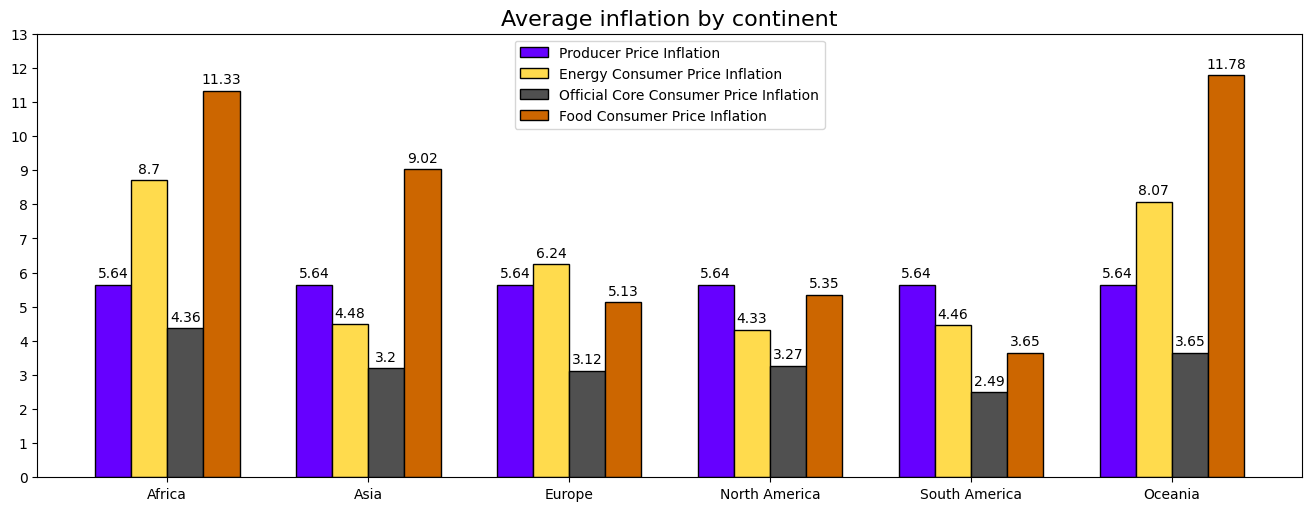

In [41]:
continents = ('Africa', 'Asia', 'Europe', 'North America', 'South America', 'Oceania')
bar_positions = np.arange(len(continents))
inflation_types = {
     'Producer Price Inflation': ppi_by_continent.Africa,
     'Energy Consumer Price Inflation': ecpi_by_continent,
     'Official Core Consumer Price Inflation': occpi_by_continent,
     'Food Consumer Price Inflation':fcpi_by_continent
    }

fig, ax = plt.subplots(figsize=(13, 5), layout='constrained')
custom_colors = ['#6600FF', '#FFDB4D', '#505050', '#CC6600']

width = 0.18
multiplier = 0
for inflation_type, values in inflation_types.items():
    offset = width * multiplier
    rects = ax.bar(bar_positions + offset, values, width, label=inflation_type, linewidth=1, edgecolor='black', color=custom_colors[multiplier])
    ax.bar_label(rects, padding=3, label_type="edge", fontsize=10)
    multiplier += 1

ax.set_yticks(np.arange(0, 13.5, 1))
ax.set_xticks(bar_positions + 0.27, continents) # 0.27 seems to be closest estimate
ax.set_xticklabels(continents)
ax.grid(False)
plt.legend()
plt.title('Average inflation by continent', fontsize=16)
plt.show()

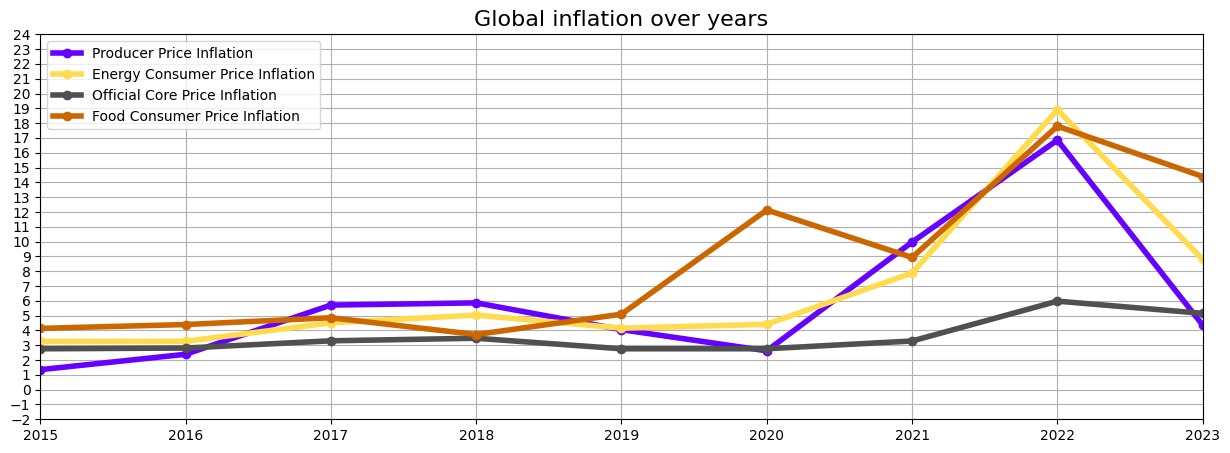

In [42]:
# GLOBAL INFLATION OVER YEARS
ppi_by_year = dataframe.groupby('Year')['Producer Price Inflation'].mean()
ecpi_by_year = dataframe.groupby('Year')['Energy Consumer Price Inflation'].mean()
occpi_by_year = dataframe.groupby('Year')['Official Core Consumer Price Inflation'].mean()
fcpi_by_year = dataframe.groupby('Year')['Food Consumer Price Inflation'].mean()

fig, ax = plt.subplots(figsize=(15, 5))
plt.xlim(2015, 2023)
plt.plot(ppi_by_year.index, ppi_by_year.values, 'o-', label='Producer Price Inflation', linewidth=4, color='#6600FF')
plt.plot(ecpi_by_year.index, ecpi_by_year.values, 'o-', label='Energy Consumer Price Inflation', linewidth=4, color='#FFDB4D')
plt.plot(occpi_by_year.index, occpi_by_year.values, 'o-', label='Official Core Price Inflation', linewidth=4, color='#505050')
plt.plot(fcpi_by_year.index, fcpi_by_year.values,  'o-', label='Food Consumer Price Inflation', linewidth=4, color='#CC6600')
ax.grid(True)
plt.yticks(ticks=np.arange(-2, 25, 1))
plt.legend()
plt.title('Global inflation over years', fontsize=16)
plt.show()

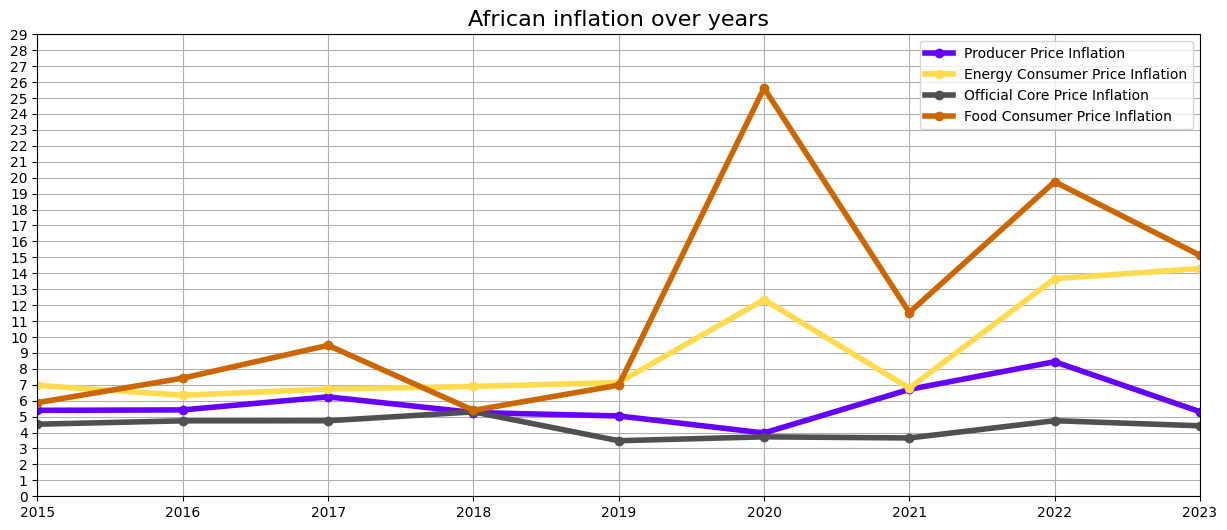

In [43]:
# AFRICAN INFLATION OVER YEARS
africa_ppi_by_year = dataframe[dataframe['Continent'] == 'Africa'].groupby('Year')['Producer Price Inflation'].mean()
africa_ecpi_by_year = dataframe[dataframe['Continent'] == 'Africa'].groupby('Year')['Energy Consumer Price Inflation'].mean()
africa_occpi_by_year = dataframe[dataframe['Continent'] == 'Africa'].groupby('Year')['Official Core Consumer Price Inflation'].mean()
africa_fcpi_by_year = dataframe[dataframe['Continent'] == 'Africa'].groupby('Year')['Food Consumer Price Inflation'].mean()

fig, ax = plt.subplots(figsize=(15, 6))
plt.xlim(2015, 2023)
plt.plot(africa_ppi_by_year.index, africa_ppi_by_year.values, 'o-', label='Producer Price Inflation', linewidth=4, color='#6600FF')
plt.plot(africa_ecpi_by_year.index, africa_ecpi_by_year.values, 'o-', label='Energy Consumer Price Inflation', linewidth=4, color='#FFDB4D')
plt.plot(africa_occpi_by_year.index, africa_occpi_by_year.values, 'o-', label='Official Core Price Inflation', linewidth=4, color='#505050')
plt.plot(africa_fcpi_by_year.index, africa_fcpi_by_year.values,  'o-', label='Food Consumer Price Inflation', linewidth=4, color='#CC6600')
ax.grid(True)
plt.yticks(ticks=np.arange(0, 30, 1))
plt.legend()
plt.title('African inflation over years', fontsize=16)
plt.show()

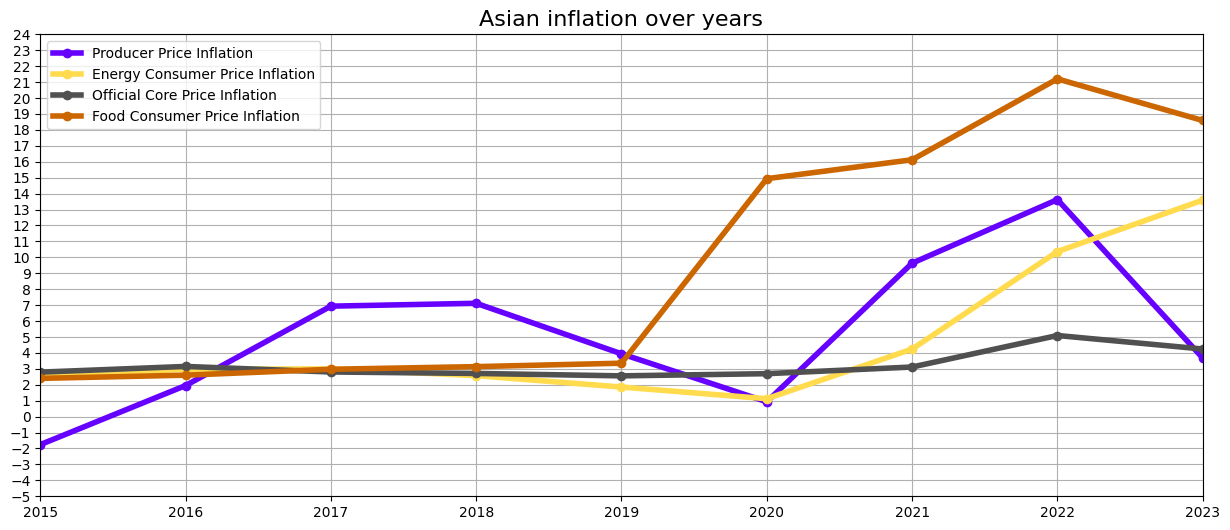

In [44]:
# ASIAN INFLATION OVER YEARS
asia_ppi_by_year = dataframe[dataframe['Continent'] == 'Asia'].groupby('Year')['Producer Price Inflation'].mean()
asia_ecpi_by_year = dataframe[dataframe['Continent'] == 'Asia'].groupby('Year')['Energy Consumer Price Inflation'].mean()
asia_occpi_by_year = dataframe[dataframe['Continent'] == 'Asia'].groupby('Year')['Official Core Consumer Price Inflation'].mean()
asia_fcpi_by_year = dataframe[dataframe['Continent'] == 'Asia'].groupby('Year')['Food Consumer Price Inflation'].mean()

fig, ax = plt.subplots(figsize=(15, 6))
plt.xlim(2015, 2023)
plt.plot(asia_ppi_by_year.index, asia_ppi_by_year.values, 'o-', label='Producer Price Inflation', linewidth=4, color='#6600FF')
plt.plot(asia_ecpi_by_year.index, asia_ecpi_by_year.values, 'o-', label='Energy Consumer Price Inflation', linewidth=4, color='#FFDB4D')
plt.plot(asia_occpi_by_year.index, asia_occpi_by_year.values, 'o-', label='Official Core Price Inflation', linewidth=4, color='#505050')
plt.plot(asia_fcpi_by_year.index, asia_fcpi_by_year.values,  'o-', label='Food Consumer Price Inflation', linewidth=4, color='#CC6600')
ax.grid(True)
plt.yticks(ticks=np.arange(-5, 25, 1))
plt.legend()
plt.title('Asian inflation over years', fontsize=16)
plt.show()

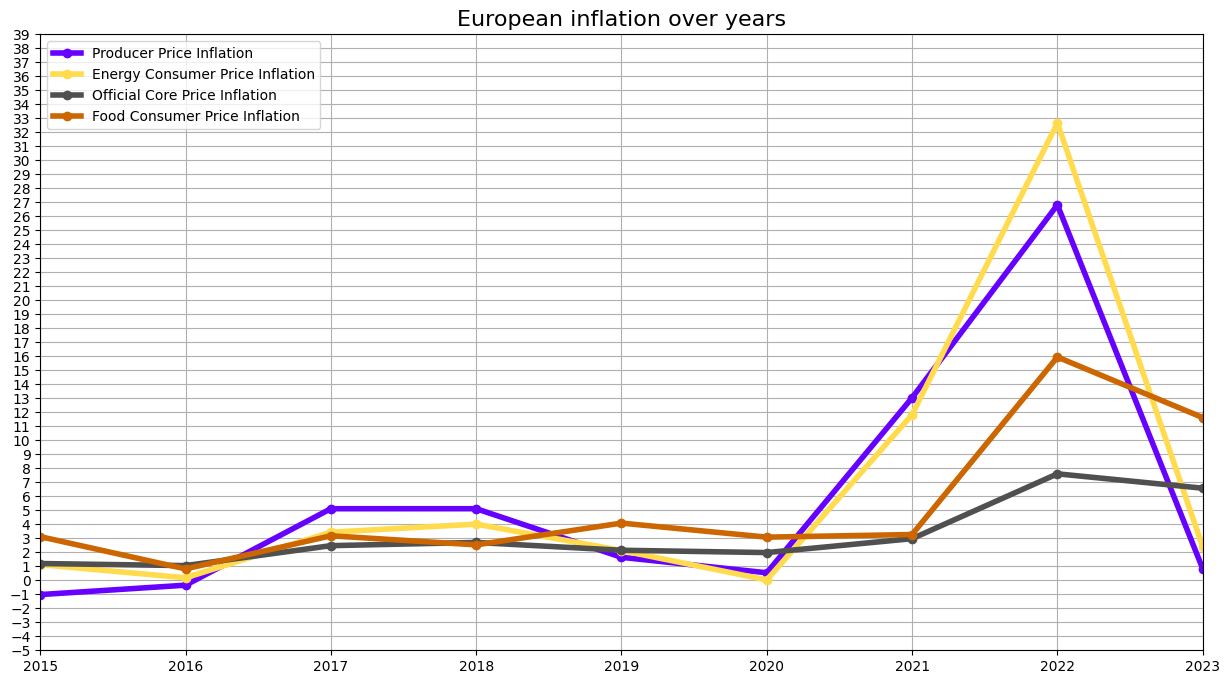

In [45]:
# EUROPEAN INFLATION OVER YEARS
europe_ppi_by_year = dataframe[dataframe['Continent'] == 'Europe'].groupby('Year')['Producer Price Inflation'].mean()
europe_ecpi_by_year = dataframe[dataframe['Continent'] == 'Europe'].groupby('Year')['Energy Consumer Price Inflation'].mean()
europe_occpi_by_year = dataframe[dataframe['Continent'] == 'Europe'].groupby('Year')['Official Core Consumer Price Inflation'].mean()
europe_fcpi_by_year = dataframe[dataframe['Continent'] == 'Europe'].groupby('Year')['Food Consumer Price Inflation'].mean()

fig, ax = plt.subplots(figsize=(15, 8))
plt.xlim(2015, 2023)
plt.plot(europe_ppi_by_year.index, europe_ppi_by_year.values, 'o-', label='Producer Price Inflation', linewidth=4, color='#6600FF')
plt.plot(europe_ecpi_by_year.index, europe_ecpi_by_year.values, 'o-', label='Energy Consumer Price Inflation', linewidth=4, color='#FFDB4D')
plt.plot(europe_occpi_by_year.index, europe_occpi_by_year.values, 'o-', label='Official Core Price Inflation', linewidth=4, color='#505050')
plt.plot(europe_fcpi_by_year.index, europe_fcpi_by_year.values,  'o-', label='Food Consumer Price Inflation', linewidth=4, color='#CC6600')
ax.grid(True)
plt.yticks(ticks=np.arange(-5, 40, 1))
plt.legend()
plt.title('European inflation over years', fontsize=16)
plt.show()

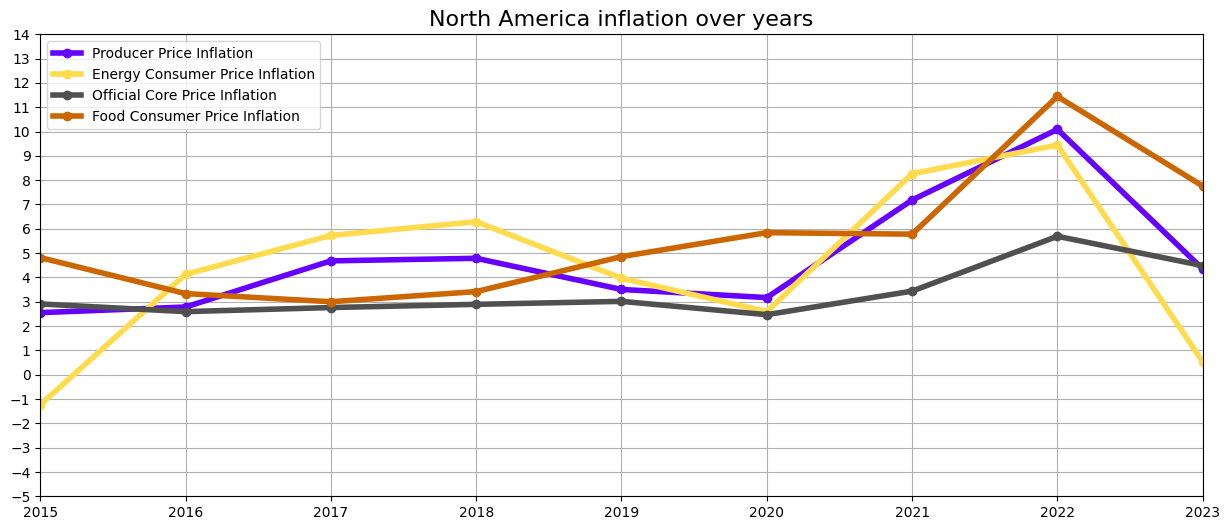

In [46]:
# NORTH AMERICAN INFLATION OVER YEARS
north_america_ppi_by_year = dataframe[dataframe['Continent'] == 'North America'].groupby('Year')['Producer Price Inflation'].mean()
north_america_ecpi_by_year = dataframe[dataframe['Continent'] == 'North America'].groupby('Year')['Energy Consumer Price Inflation'].mean()
north_america_occpi_by_year = dataframe[dataframe['Continent'] == 'North America'].groupby('Year')['Official Core Consumer Price Inflation'].mean()
north_america_fcpi_by_year = dataframe[dataframe['Continent'] == 'North America'].groupby('Year')['Food Consumer Price Inflation'].mean()

fig, ax = plt.subplots(figsize=(15, 6))
plt.xlim(2015, 2023)
plt.plot(north_america_ppi_by_year.index, north_america_ppi_by_year.values, 'o-', label='Producer Price Inflation', linewidth=4, color='#6600FF')
plt.plot(north_america_ecpi_by_year.index, north_america_ecpi_by_year.values, 'o-', label='Energy Consumer Price Inflation', linewidth=4, color='#FFDB4D')
plt.plot(north_america_occpi_by_year.index, north_america_occpi_by_year.values, 'o-', label='Official Core Price Inflation', linewidth=4, color='#505050')
plt.plot(north_america_fcpi_by_year.index, north_america_fcpi_by_year.values,  'o-', label='Food Consumer Price Inflation', linewidth=4, color='#CC6600')
ax.grid(True)
plt.yticks(ticks=np.arange(-5, 15, 1))
plt.legend()
plt.title('North America inflation over years', fontsize=16)
plt.show()

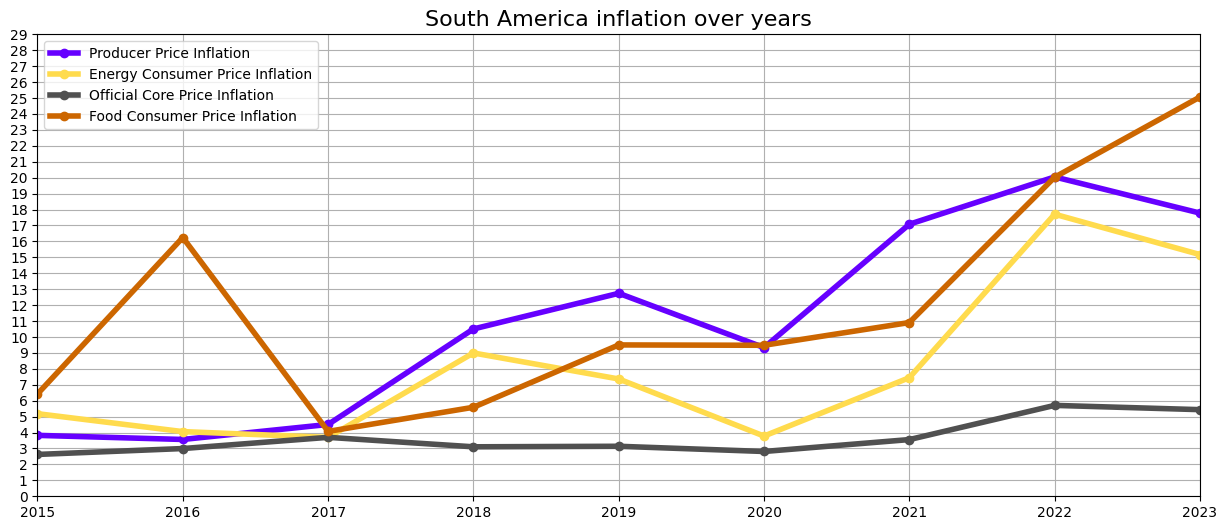

In [47]:
# SOUTH AMERICAN INFLATION OVER YEARS
south_america_ppi_by_year = dataframe[dataframe['Continent'] == 'South America'].groupby('Year')['Producer Price Inflation'].mean()
south_america_ecpi_by_year = dataframe[dataframe['Continent'] == 'South America'].groupby('Year')['Energy Consumer Price Inflation'].mean()
south_america_occpi_by_year = dataframe[dataframe['Continent'] == 'South America'].groupby('Year')['Official Core Consumer Price Inflation'].mean()
south_america_fcpi_by_year = dataframe[dataframe['Continent'] == 'South America'].groupby('Year')['Food Consumer Price Inflation'].mean()

fig, ax = plt.subplots(figsize=(15, 6))
plt.xlim(2015, 2023)
plt.plot(south_america_ppi_by_year.index, south_america_ppi_by_year.values, 'o-', label='Producer Price Inflation', linewidth=4, color='#6600FF')
plt.plot(south_america_ecpi_by_year.index, south_america_ecpi_by_year.values, 'o-', label='Energy Consumer Price Inflation', linewidth=4, color='#FFDB4D')
plt.plot(south_america_occpi_by_year.index, south_america_occpi_by_year.values, 'o-', label='Official Core Price Inflation', linewidth=4, color='#505050')
plt.plot(south_america_fcpi_by_year.index, south_america_fcpi_by_year.values,  'o-', label='Food Consumer Price Inflation', linewidth=4, color='#CC6600')
ax.grid(True)
plt.yticks(ticks=np.arange(0, 30, 1))
plt.legend()
plt.title('South America inflation over years', fontsize=16)
plt.show()

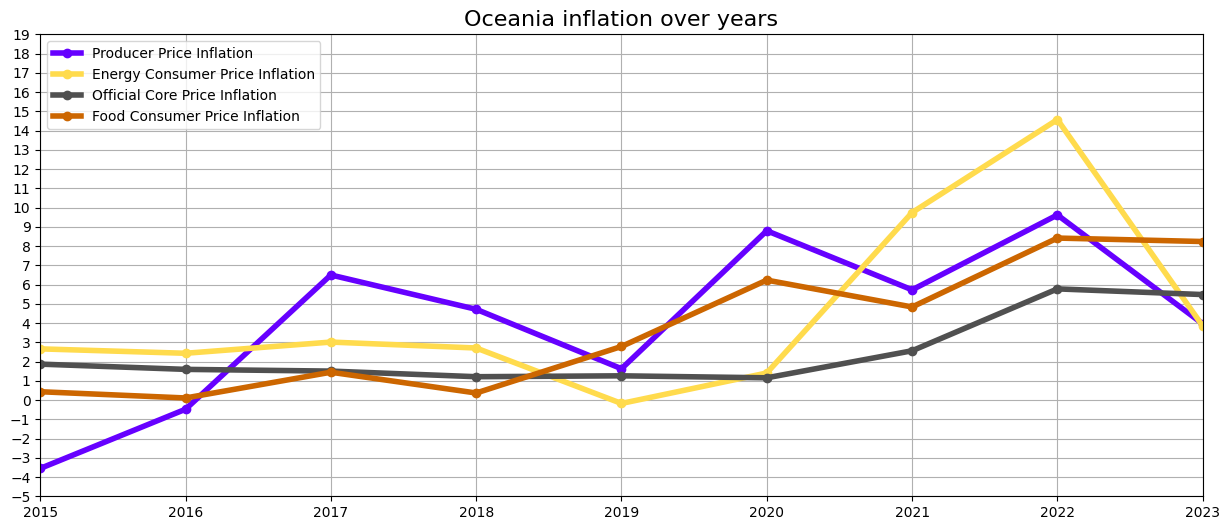

In [48]:
# OCEANIAN INFLATION OVER YEARS
oceania_ppi_by_year = dataframe[dataframe['Continent'] == 'Oceania'].groupby('Year')['Producer Price Inflation'].mean()
oceania_ecpi_by_year = dataframe[dataframe['Continent'] == 'Oceania'].groupby('Year')['Energy Consumer Price Inflation'].mean()
oceania_occpi_by_year = dataframe[dataframe['Continent'] == 'Oceania'].groupby('Year')['Official Core Consumer Price Inflation'].mean()
oceania_fcpi_by_year = dataframe[dataframe['Continent'] == 'Oceania'].groupby('Year')['Food Consumer Price Inflation'].mean()

fig, ax = plt.subplots(figsize=(15, 6))
plt.xlim(2015, 2023)
plt.plot(oceania_ppi_by_year.index, oceania_ppi_by_year.values, 'o-', label='Producer Price Inflation', linewidth=4, color='#6600FF')
plt.plot(oceania_ecpi_by_year.index, oceania_ecpi_by_year.values, 'o-', label='Energy Consumer Price Inflation', linewidth=4, color='#FFDB4D')
plt.plot(oceania_occpi_by_year.index, oceania_occpi_by_year.values, 'o-', label='Official Core Price Inflation', linewidth=4, color='#505050')
plt.plot(oceania_fcpi_by_year.index, oceania_fcpi_by_year.values,  'o-', label='Food Consumer Price Inflation', linewidth=4, color='#CC6600')
ax.grid(True)
plt.yticks(ticks=np.arange(-5, 20, 1))
plt.legend()
plt.title('Oceania inflation over years', fontsize=16)
plt.show()

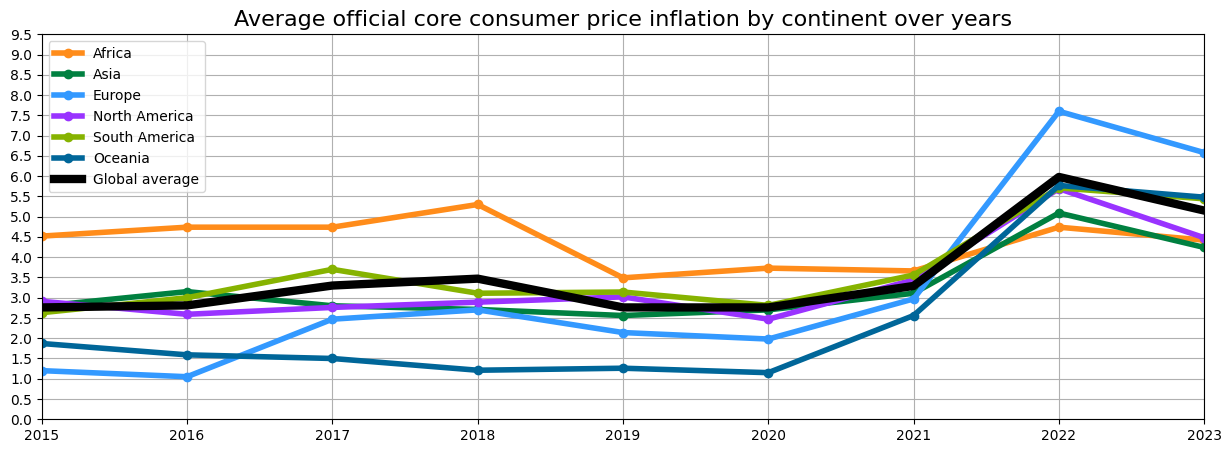

In [49]:
# OFFICIAL CORE CONSUMER PRICE INFLATION BY CONTINENT OVER YEARS
avg_occpi_globally = dataframe.groupby('Year')['Official Core Consumer Price Inflation'].mean().round(2)
africa_occpi_by_year = dataframe[dataframe['Continent'] == 'Africa'].groupby('Year')['Official Core Consumer Price Inflation'].mean().round(2)
asia_occpi_by_year = dataframe[dataframe['Continent'] == 'Asia'].groupby('Year')['Official Core Consumer Price Inflation'].mean().round(2)
europe_occpi_by_year = dataframe[dataframe['Continent'] == 'Europe'].groupby('Year')['Official Core Consumer Price Inflation'].mean().round(2)
north_america_occpi_by_year = dataframe[dataframe['Continent'] == 'North America'].groupby('Year')['Official Core Consumer Price Inflation'].mean().round(2)
south_america_occpi_by_year = dataframe[dataframe['Continent'] == 'South America'].groupby('Year')['Official Core Consumer Price Inflation'].mean().round(2)
oceania_occpi_by_year = dataframe[dataframe['Continent'] == 'Oceania'].groupby('Year')['Official Core Consumer Price Inflation'].mean().round(2)

fig, ax = plt.subplots(figsize=(15, 5))
plt.xlim(2015, 2023)
plt.plot(africa_occpi_by_year.index, africa_occpi_by_year.values, 'o-', label='Africa', linewidth=4, color=africa_color)
plt.plot(asia_occpi_by_year.index, asia_occpi_by_year.values, 'o-', label='Asia', linewidth=4, color=asia_color)
plt.plot(europe_occpi_by_year.index, europe_occpi_by_year.values, 'o-', label='Europe', linewidth=4, color=europe_color)
plt.plot(north_america_occpi_by_year.index, north_america_occpi_by_year.values, 'o-', label='North America', linewidth=4, color=north_america_color)
plt.plot(south_america_occpi_by_year.index, south_america_occpi_by_year.values, 'o-', label='South America', linewidth=4, color=south_america_color)
plt.plot(oceania_occpi_by_year.index, oceania_occpi_by_year.values, 'o-', label='Oceania', linewidth=4, color=oceania_color)
plt.plot(avg_occpi_globally.index, avg_occpi_globally.values, label='Global average', linewidth=6, color='black')
ax.grid(True)
ax.set_yticks(np.arange(0, 10, 0.5))
plt.legend()
plt.title('Average official core consumer price inflation by continent over years', fontsize=16)
plt.show()



---

Udział państw o indeksie szczęśliwości wyższym i niższym, niż światowa średnia.

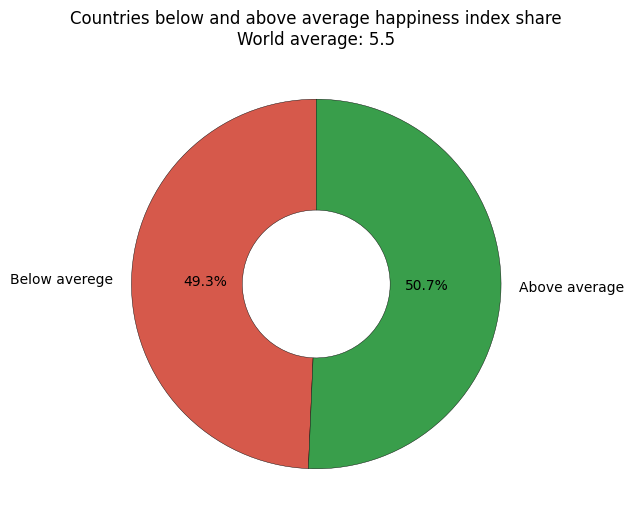

In [50]:
avg_happiness = dataframe['Score'].mean().round(2)
countries_happiness = dataframe.groupby('Country')['Score'].mean().round(2)
countries_below = countries_happiness[countries_happiness < avg_happiness]
countries_above = countries_happiness[countries_happiness > avg_happiness]

labels = ['Below averege', 'Above average']
values = [len(countries_below), len(countries_above)]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#d6594b', '#399e4b'], wedgeprops=dict(width=0.6, edgecolor='black', linewidth=0.3))
plt.title('Countries below and above average happiness index share\n' + 'World average: ' + str(avg_happiness))
plt.show()

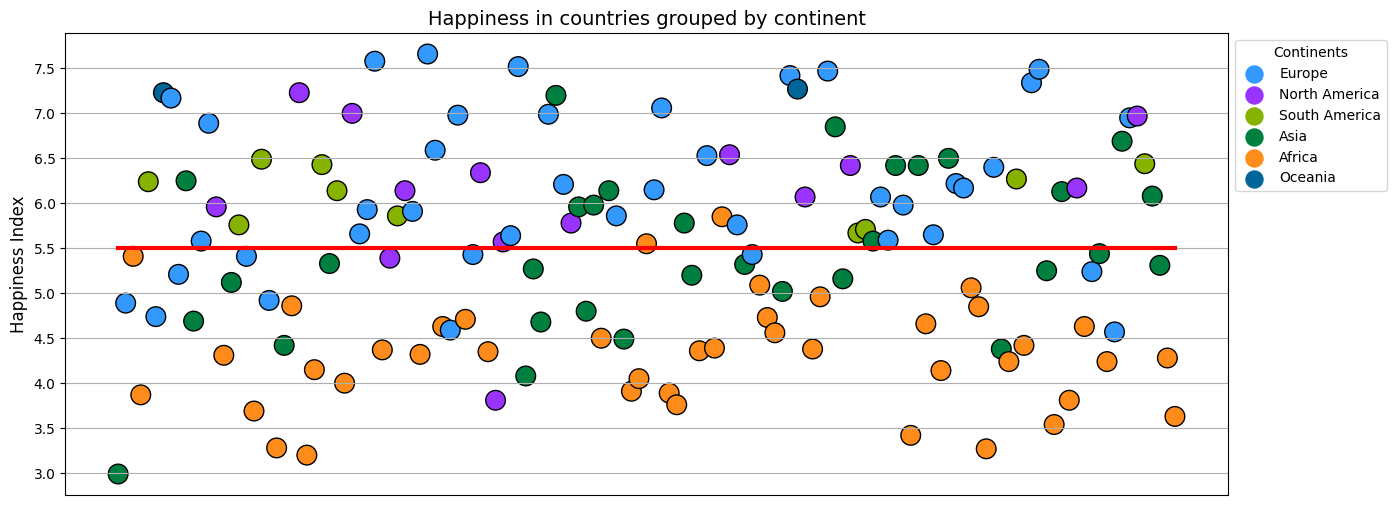

In [51]:
continent_colors_map = {
    'Europe': europe_color,
    'North America': north_america_color,
    'South America': south_america_color,
    'Asia': asia_color,
    'Africa': africa_color,
    'Oceania': oceania_color
}

countries_continents_score = dataframe.groupby(['Country', 'Continent'])['Score'].mean().round(2).reset_index()
countries_continents_score['Color'] = countries_continents_score['Continent'].map(continent_colors_map)

x_positions = np.arange(len(countries_continents_score))

plt.figure(figsize=(15, 6))
plt.scatter(x_positions, countries_continents_score['Score'], c=countries_continents_score['Color'], s=200, edgecolors='black')
plt.plot(x_positions, avg_happiness * np.ones(len(countries_continents_score)), color='red', linestyle='-', linewidth=3)
plt.xticks([])
plt.ylabel("Happiness Index", fontsize=12)
plt.yticks(ticks=np.arange(0, 9, 0.5))
plt.title("Happiness in countries grouped by continent", fontsize=14)
plt.grid(True)

# legend
for continent, color in continent_colors_map.items():
    plt.scatter([], [], c=color, label=continent, s=150)
plt.legend(title="Continents", loc='upper left', bbox_to_anchor=(1, 1))

plt.show()

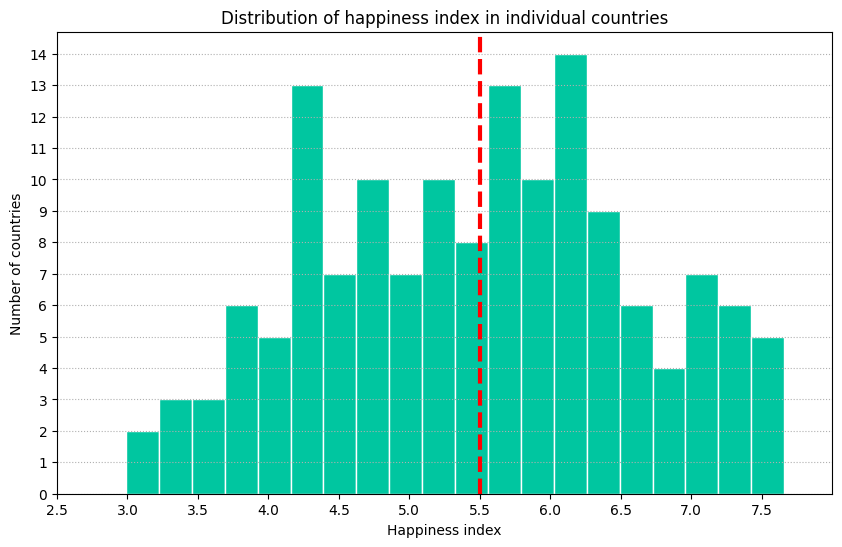

In [52]:
happiness_by_country = dataframe.groupby('Country')['Score'].mean().round(2)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(happiness_by_country, bins=20, color='#00c6a0', edgecolor='white')
ax.axvline(avg_happiness, color='red', linestyle='dashed', linewidth=3)
ax.set_xlim(3, 8)
ax.set_xticks(np.arange(2.5, 8, 0.5))
ax.set_yticks(np.arange(0, 15, 1))
plt.xlabel("Happiness index")
plt.ylabel("Number of countries")
plt.title("Distribution of happiness index in individual countries")
plt.grid(axis='y', linestyle=':', alpha=1)

plt.show()

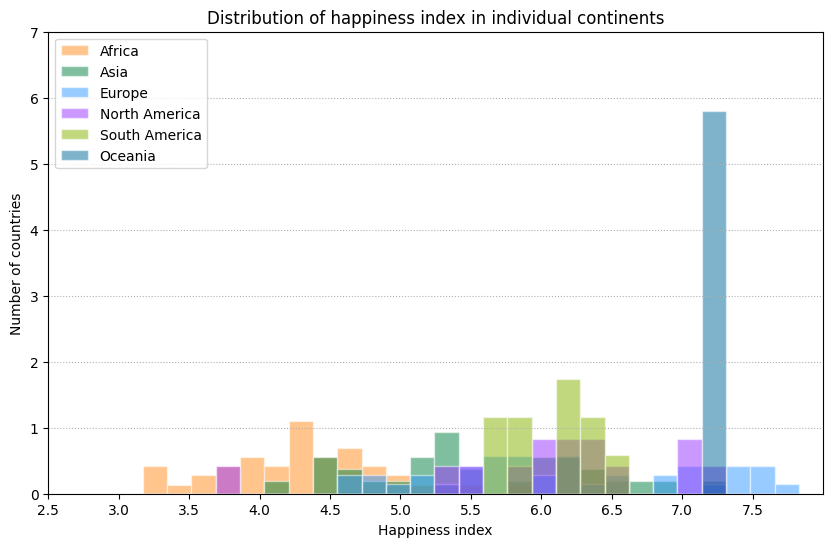

In [75]:
africa_happiness_by_country = dataframe[dataframe['Continent'] == 'Africa'].groupby('Country')['Score'].mean().round(2)
asia_happiness_by_country = dataframe[dataframe['Continent'] == 'Asia'].groupby('Country')['Score'].mean().round(2)
europe_happiness_by_country = dataframe[dataframe['Continent'] == 'Europe'].groupby('Country')['Score'].mean().round(2)
north_america_happiness_by_country = dataframe[dataframe['Continent'] == 'North America'].groupby('Country')['Score'].mean().round(2)
south_america_happiness_by_country = dataframe[dataframe['Continent'] == 'South America'].groupby('Country')['Score'].mean().round(2)
oceania_happiness_by_country = dataframe[dataframe['Continent'] == 'Oceania'].groupby('Country')['Score'].mean().round(2)


fig, ax = plt.subplots(figsize=(10, 6))

alpha = 0.5
bins = np.linspace(3, 8, 30)
ax.hist(africa_happiness_by_country, bins=bins, color=africa_color, edgecolor='white', alpha=alpha, density=True, label='Africa')
ax.hist(asia_happiness_by_country, bins=bins, color=asia_color, edgecolor='white', alpha=alpha, density=True, label='Asia')
ax.hist(europe_happiness_by_country, bins=bins, color=europe_color, edgecolor='white', alpha=alpha, density=True, label='Europe')
ax.hist(north_america_happiness_by_country, bins=bins, color=north_america_color, edgecolor='white', alpha=alpha, density=True, label='North America')
ax.hist(south_america_happiness_by_country, bins=bins, color=south_america_color, edgecolor='white', alpha=alpha, density=True, label='South America')
ax.hist(oceania_happiness_by_country, bins=bins, color=oceania_color, edgecolor='white', alpha=alpha, density=True, label='Oceania')

ax.set_xlim(3, 8)
ax.set_xticks(np.arange(2.5, 8, 0.5))
ax.set_yticks(np.arange(0, 8, 1))
plt.xlabel("Happiness index")
plt.ylabel("Number of countries")
plt.title("Distribution of happiness index in individual continents")
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=1)

plt.show()



---

Przegląd korelacji między danymi w kolumnach

<Axes: >

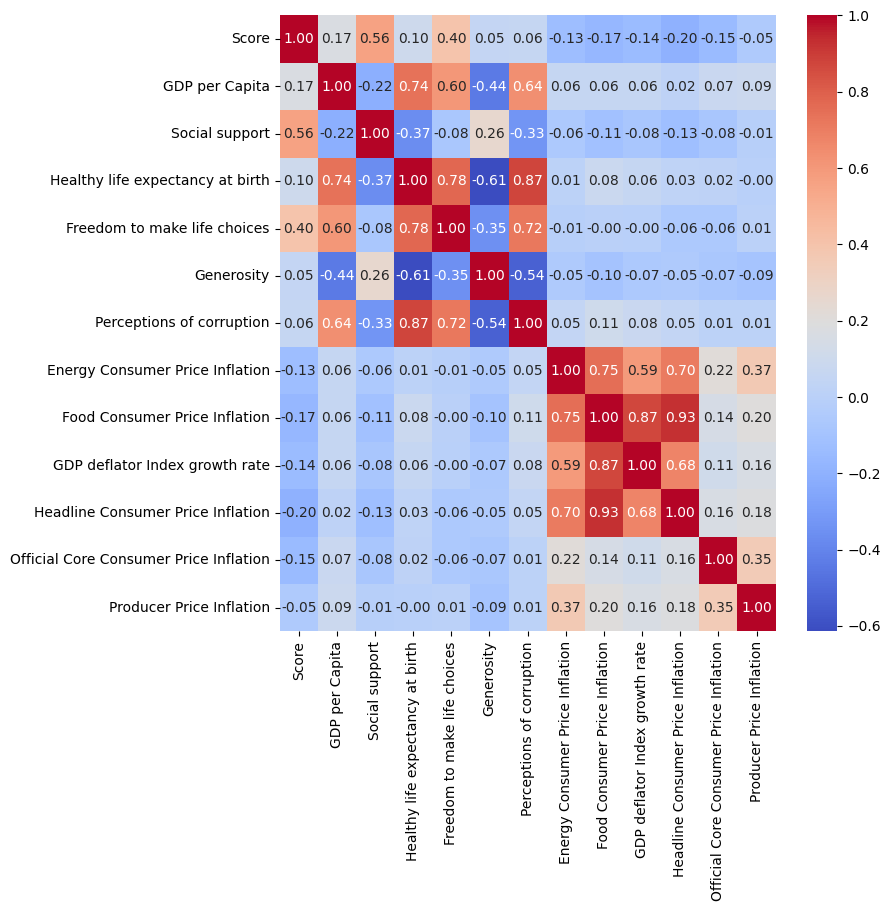

In [88]:
import seaborn as sns

excluded_columns = ['Country', 'Year', 'Continent', 'Rank']
data_for_correlation_research = dataframe.drop(columns=excluded_columns).corr()

ax, fig = plt.subplots(figsize=(8, 8))
sns.heatmap(data_for_correlation_research, annot=True, cmap='coolwarm', fmt=".2f")

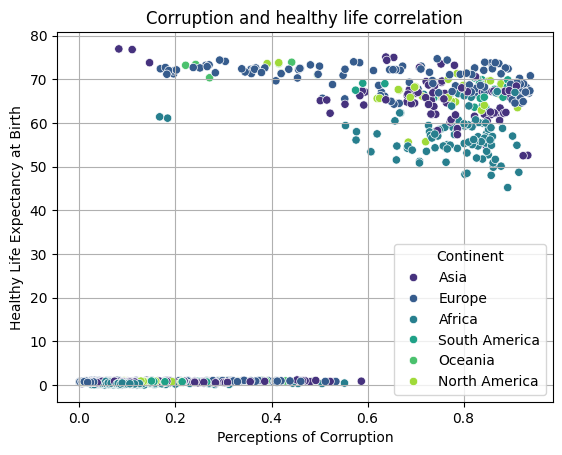

In [97]:
sns.scatterplot(x=dataframe['Perceptions of corruption'], y=dataframe['Healthy life expectancy at birth'], hue=dataframe['Continent'], palette='viridis')

plt.xlabel("Perceptions of Corruption")
plt.ylabel("Healthy Life Expectancy at Birth")
plt.title("Corruption and healthy life correlation")
plt.grid(True)
plt.show()